In [64]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind
from scipy.stats import chisquare
from scipy.stats import norm

from statsmodels.stats.proportion import proportions_ztest

In [2]:
sns.set_theme('notebook')
sns.set_style('whitegrid')

In [70]:
data = pd.read_csv('./data/ab_data.csv', date_format='timestamp')
contr = pd.read_csv('./data/countries.csv')

data = data.merge(contr, on='user_id', how='left')

### EDA

In [4]:
data.head()

,user_id,timestamp,group,landing_page,converted,country
0,851104,11:48.6,control,old_page,0,US
1,804228,01:45.2,control,old_page,0,US
2,661590,55:06.2,treatment,new_page,0,US
3,853541,28:03.1,treatment,new_page,0,US
4,864975,52:26.2,control,old_page,1,US


In [5]:
data.isna().sum()

user_id         0
timestamp       0
group           0
landing_page    0
converted       0
country         0
dtype: int64

In [6]:
data[((data['group'] == 'treatment') & (data['landing_page'] == 'old_page')) | 
     ((data['group'] == 'control') & (data['landing_page'] == 'new_page'))]


,user_id,timestamp,group,landing_page,converted,country
22,767017,58:15.0,control,new_page,0,US
240,733976,11:16.4,control,new_page,0,US
308,857184,34:59.8,treatment,old_page,0,US
327,686623,26:40.7,treatment,old_page,0,US
357,856078,29:30.4,treatment,old_page,0,US
...,...,...,...,...,...,...
294015,813406,25:33.2,treatment,old_page,0,UK
294201,928506,32:10.5,control,new_page,0,US
294253,892498,11:10.5,treatment,old_page,0,US
294254,886135,49:20.5,control,new_page,0,UK


Убираем юзеров, неудовлетворяющих условию эксперимента

In [74]:
print(data.shape)
data = data[((data['group'] == 'treatment') & (data['landing_page'] == 'new_page')) | 
     ((data['group'] == 'control') & (data['landing_page'] == 'old_page'))]


(294482, 6)


In [75]:
print(data.shape)
data = data.drop_duplicates(subset= 'user_id', keep='first') 
print(data.shape)

(290589, 6)
(290585, 6)


Тестовая группа наблюдала новую страницу.

Контрольная группа наблюдала старую страницу.

In [76]:
pd.concat([data.groupby('group')['converted'].value_counts(),
 data.groupby('group')['converted'].value_counts(normalize=True)
], axis=1)

count  proportion
group     converted                    
control   0          127785    0.879614
          1           17489    0.120386
treatment 0          128047    0.881193
          1           17264    0.118807

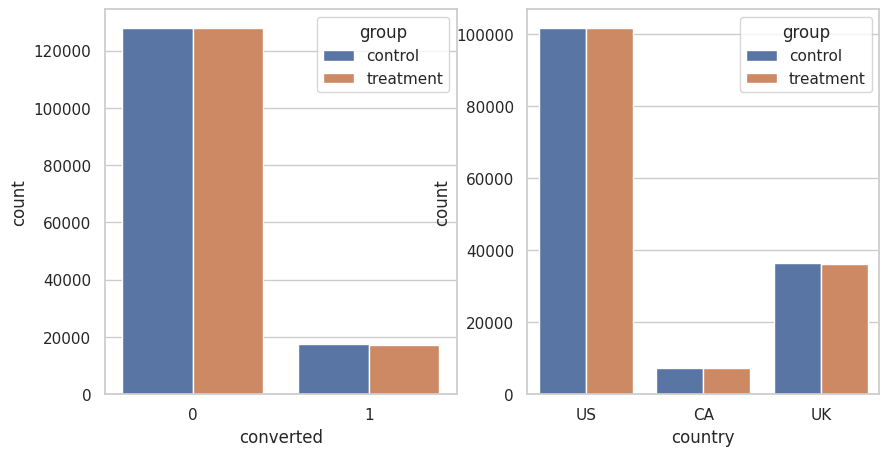

In [77]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))
sns.countplot(data=data, x='converted',  hue='group', ax=ax1)
sns.countplot(data=data, x='country',  hue='group', ax=ax2)
plt.show()

In [78]:
pd.concat([data['group'].value_counts(normalize=True),
           data['group'].value_counts(),
           data.groupby('group')['converted'].agg(['sum'])
          ],axis=1)

,proportion,count,sum
group,,,
treatment,0.500064,145311,17264
control,0.499936,145274,17489


### SRM

- $H_0$: $P(Control)=P(Treatment)=0.5$
- $H_1$: $P(Control) \ne P(Treatment)$

In [79]:
cnt = data['group'].value_counts().values
expect = np.array([0.5, 0.5]) * cnt.sum()

chi_stat, p_val = chisquare(cnt, f_exp=expect)
print(f'{chi_stat:.5f}, {p_val:.5f}')

0.00471, 0.94528


Нет достаточных оснований, чтобы отклонить $H_0$.

### Тесты

$\alpha = 0.05$, $\beta = 0.2$
- $H_0$: конверсия контрольной группы равна конверсии тестовой группы, $P(contorl)$ = $P(test)$ 
- $H_1$: конверсия контрольной группы $\ne$ конверсии тестовой группы, $P(contorl) \ne P(test)$

In [80]:
def do_Z_test(data: pd.DataFrame, alpha: float = 0.05) -> None:
    agg_data = data.groupby('group')['converted'].agg(['sum', 'size'])

    count = [agg_data.loc['control', 'sum'], agg_data.loc['treatment', 'sum']]
    nobs = [agg_data.loc['control', 'size'], agg_data.loc['treatment', 'size']]

    test_stat, p_val = np.round(proportions_ztest(count=count, nobs=nobs), 5)


    if (p_val < alpha):
        print(f'{p_val} < {alpha} - можем отвергунть H0, принимаем H1')
    else:
        print(f'{p_val} > {alpha} - не существуют статистически значимых причин, чтобы отвергнуть H0')
    print(f'Статистика критерия: {test_stat}')


def do_casual_bootstrap(data: pd.DataFrame, column: str = 'converted', times: int = 5000, alpha: float = .05) -> tuple[list[float], float, float]:
    data_treat = data[data['group'] == 'treatment'][column]
    data_contr = data[data['group'] == 'control'][column]

    diffs = []
    for _ in range(times):
        rand_treat = np.random.choice(data_treat, data_treat.size, replace=True).mean()
        rand_contr = np.random.choice(data_contr, data_contr.size, replace=True).mean()

        diff = rand_treat - rand_contr
        diffs.append(diff)
    
    lower_bound = np.round(np.quantile(diffs, alpha / 2), 5)
    upper_bound = np.round(np.quantile(diffs, 1 - (alpha / 2)), 5)

    return diffs, lower_bound, upper_bound
        
        
def do_poisson_bootstrap(data : pd.DataFrame, times: float = 1000, alpha: float = .05) -> tuple[list[float], float, float]:
    contr = data[data['group'] == 'control']['converted'].to_numpy()
    treat = data[data['group'] == 'treatment']['converted'].to_numpy()

    diffs = []
    for _ in range(times):
        contr_weights = np.random.poisson(1.0, size=contr.size)
        treat_weights = np.random.poisson(1.0, size=treat.size)

        boot_contr = np.sum(contr_weights * contr) / np.sum(contr_weights + 1e-10)
        boot_treat_num = np.sum(treat_weights * treat) / np.sum(treat_weights + 1e-10)
        delta = boot_treat_num - boot_contr
        diffs.append(delta)
    
    lower_bound = np.round(np.quantile(diffs, alpha / 2), 5)
    upper_bound = np.round(np.quantile(diffs, 1 - (alpha / 2)), 5)
    
    return diffs, lower_bound, upper_bound


def plot_boot(diff: list, lb: float, ub: float) -> None:
    plt.figure(figsize = (7, 5))

    print(f'CI bootstrap: {lb:.3f}, {ub:.3f}')

    sns.histplot(x=diff, kde=True)
    plt.title(r'Графики распределения $\Delta$')
    plt.axvline(x=lb, color='r', linestyle='--', linewidth=2, label='CI')
    plt.axvline(x=ub, color='r', linestyle='--', linewidth=2)
    plt.axvline(x=0.0, color='g', linestyle='--', linewidth=2, label='0')

    plt.legend()
    plt.show()


In [81]:
do_Z_test(data)

0.18965 > 0.05 - не существуют статистически значимых причин, чтобы отвергнуть H0
Статистика критерия: 1.31161


In [82]:
diffs_poisson, lbp, ubp = do_poisson_bootstrap(data, times=5000)

CI bootstrap: -0.004, 0.001


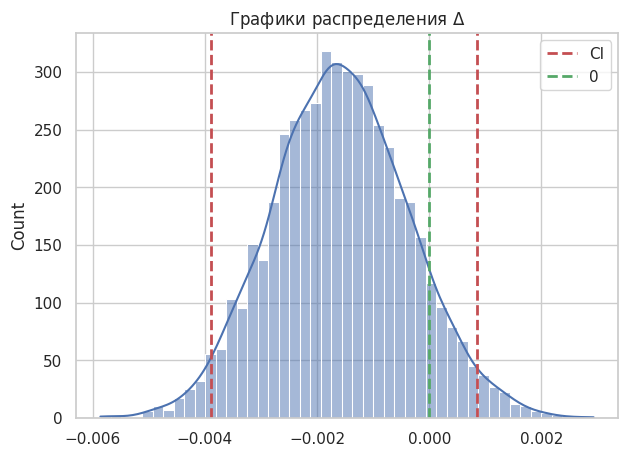

In [83]:
plot_boot(diffs_poisson, lbp, ubp)

### Генерация выручки и проведеление тестирования новых данных
- converted = 1 интерпретируется как факт покупки.
- Пусть, например, новая страница содержит блок рекомендации, в таком случае конверсия не изменилась, но средний чек должен увеличиться

Сгенерируем выборки так, что в тестовой группе будет эффект в 5%. Для начала убедимся что нам хватает данных, чтобы заметить такой эффект.
- $\alpha$ = 0.05
- $\beta$ = 0.2


In [84]:
def mde(data: pd.DataFrame, alpha: float, beta: float) -> None:
    n = data[data['group'] == 'control']['converted'].size
    m = data[data['group'] == 'treatment']['converted'].size

    std_n = np.var(data[data['group'] == 'control']['revenue'], ddof=True)
    std_m = np.var(data[data['group'] == 'treatment']['revenue'], ddof=True)

    alpha_quant = norm.ppf(1 - alpha/2, 0, 1)
    beta_quant = norm.ppf(1 - beta, 0, 1)
    k = m / n

    mde = (alpha_quant + beta_quant) * np.sqrt((std_n / n) + (std_m / m))

    print(f'{mde:.5f}')
    


def gen_exp_revenue_data(data: pd.DataFrame, mu_exp: int = 500, effect: float = 0.05) -> pd.DataFrame:

    X = data.copy()
    n = data.shape[0]

    converted_contr = np.random.exponential(mu_exp, size=n)
    converted_treat = np.random.exponential(mu_exp * (1 + effect), size=n)

    revenue_column = np.where(data['group'] == 'treatment', converted_treat, converted_contr)
    revenue_column = data['converted'] * revenue_column

    X['revenue'] = revenue_column
    return X


In [85]:
data_revenue = gen_exp_revenue_data(data)

In [86]:
data_revenue.head()

,user_id,timestamp,group,landing_page,converted,country,revenue
0,851104,11:48.6,control,old_page,0,US,0.000000
1,804228,01:45.2,control,old_page,0,US,0.000000
2,661590,55:06.2,treatment,new_page,0,US,0.000000
3,853541,28:03.1,treatment,new_page,0,US,0.000000
4,864975,52:26.2,control,old_page,1,US,68.443422


In [87]:
print('NaNs sum = ', data_revenue['revenue'].isna().sum())
print(data_revenue.groupby('group')['revenue'].agg(['mean', 'sum']))

NaNs sum =  0
                mean           sum
group                             
control    60.394066  8.773688e+06
treatment  62.659189  9.105069e+06


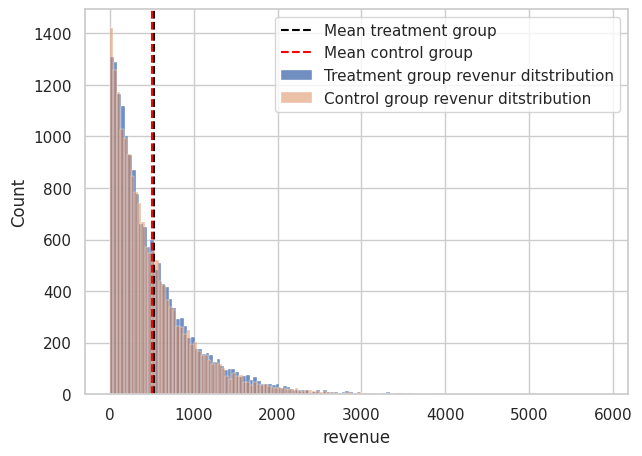

In [88]:
plt.subplots(figsize=(7, 5))

revenue_treat = data_revenue[(data_revenue['group'] == 'treatment') & (data_revenue['converted'] == 1)]['revenue']
revenue_contr = data_revenue[(data_revenue['group'] == 'control') & (data_revenue['converted'] == 1)]['revenue']

sns.histplot(revenue_treat, alpha=0.8, label='Treatment group revenur ditstribution')
sns.histplot(revenue_contr, alpha=0.5,  label='Control group revenur ditstribution')
plt.axvline(x=np.mean(revenue_treat), c='black', linestyle='--', label='Mean treatment group')
plt.axvline(x=np.mean(revenue_contr), c='red', linestyle='--', label='Mean control group')
plt.legend()
plt.show()

In [89]:
mde(data_revenue, alpha=0.05, beta=0.2)

2.54302


При текущих размерах выборки мы можем заметить изменения на 2.55 денежных единиц (я не знаю какая у меня валюта).
Так что если эффект есть, мы увидим его с вероятностью >0.8.

### Тест

- $H_0$: $\overline{X_{t}} = \overline{X_{с}}$ 
- $H_1$: $\overline{X_{t}} \ne \overline{X_{с}}$ 

In [90]:
def do_ttest(data: pd.DataFrame, alpha: float = 0.05) -> None:
    contr = data[data['group'] == 'control']['revenue']
    treat = data[data['group'] == 'treatment']['revenue']

    test_stat, p_val = ttest_ind(contr, treat)

    if (p_val < alpha):
        print(f'{p_val:.5f} < {alpha} -- можем отвергунть H0, принимаем H1')
    else:
        print(f'{p_val:.5f} > {alpha} -- не существуют статистически значимых причин, чтобы отвергнуть H0')
    print(f'Статистика критерия: {test_stat:.5f}')

    

In [91]:
do_ttest(data_revenue)

0.01258 < 0.05 -- можем отвергунть H0, принимаем H1
Статистика критерия: -2.49542


In [92]:
diffs_r, lb_r, up_r = do_casual_bootstrap(data_revenue, 'revenue', times=5000)

CI bootstrap: 0.539, 4.040


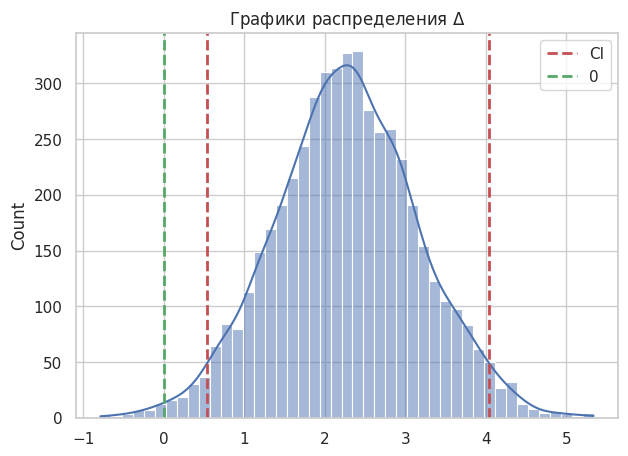

In [93]:
plot_boot(diffs_r, lb_r, up_r)